In [1]:
import pandas as pd 

In [7]:
data = pd.read_csv('../Data/train.csv')

In [4]:
data[data['Street'] != 'Pave']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
52,53,90,RM,110.0,8472,Grvl,NaN,IR2,Bnk,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,110000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
582,583,90,RL,81.0,11841,Grvl,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,118500
812,813,20,C (all),66.0,8712,Grvl,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,Shed,54,6,2010,WD,Alloca,55993
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1184,1185,20,RL,50.0,35133,Grvl,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,186700


In [5]:
data[data['Utilities'] != 'AllPub']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
944,945,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,NoSeWa,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500


In [6]:
#proly should just delete Utilites column
data.drop('Utilities', axis=1, inplace=True)

In [7]:
#same for street column
data.drop('Street', axis=1, inplace=True)

In [8]:
data['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [9]:
data['Alley'].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [10]:
data[data['MSSubClass'] == 'nan']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [11]:
data['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [12]:
data[data['MSZoning'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [13]:
data[data['LotFrontage'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
7,8,60,RL,NaN,10382,NaN,IR1,Lvl,Corner,Gtl,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
12,13,20,RL,NaN,12968,NaN,IR2,Lvl,Inside,Gtl,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000
14,15,20,RL,NaN,10920,NaN,IR1,Lvl,Corner,Gtl,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,157000
16,17,20,RL,NaN,11241,NaN,IR1,Lvl,CulDSac,Gtl,...,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
24,25,20,RL,NaN,8246,NaN,IR1,Lvl,Inside,Gtl,...,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,1430,20,RL,NaN,12546,NaN,IR1,Lvl,Corner,Gtl,...,0,NaN,NaN,NaN,0,4,2007,WD,Normal,182900
1431,1432,120,RL,NaN,4928,NaN,IR1,Lvl,Inside,Gtl,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,143750
1441,1442,120,RM,NaN,4426,NaN,Reg,Lvl,Inside,Gtl,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,149300
1443,1444,30,RL,NaN,8854,NaN,Reg,Lvl,Inside,Gtl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,121000


In [14]:
#Bước 1: xóa các cột nhiều Nan hoặc giá trị lặp lại (ở trên đã drop cột Street và Utilities)
def dropCols(df, column_list):
    """
    function to drop unnecessary columns
    """
    df_reduced = df.drop(columns = column_list)
    return df_reduced

column_list = []
data = dropCols(data, column_list)

In [15]:
#To execute step 1 we will check columns to see which one of them has a lot of redundant data
print(data['LandContour'].value_counts(dropna=False))
print(data['LandSlope'].value_counts(dropna=False))
print(data['Condition2'].value_counts(dropna=False))
#we see there are many 'Norms', let's check if houses with Condition2 != 'Norm' has weird values
print(data.groupby('Condition2')['SalePrice'].mean())
#there are indeed weirdly high values, but proly just noises, so I'll drop the column anyways :p
data.drop('Condition2', axis = 1, inplace=True)

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64
Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64
Condition2
Artery    106500.000000
Feedr     121166.666667
Norm      181169.405536
PosA      325000.000000
PosN      284875.000000
RRAe      190000.000000
RRAn      136905.000000
RRNn       96750.000000
Name: SalePrice, dtype: float64


In [16]:
#continuing checking columns
print(data['BldgType'].value_counts(dropna=False))
print(data['RoofMatl'].value_counts(dropna=False))
#proly should check RoofMatl and SalePrice relationship

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64
RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64


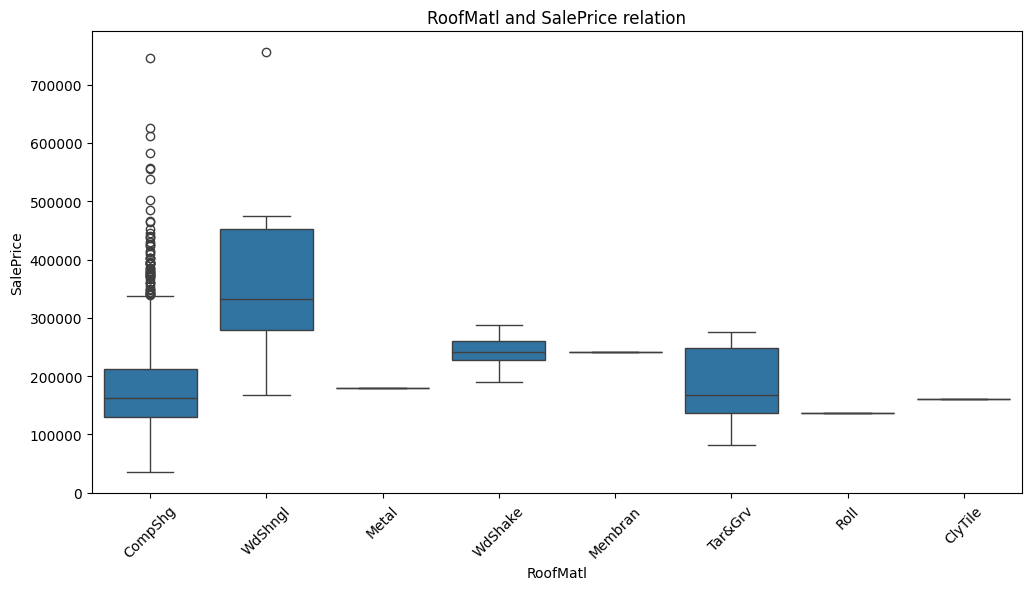

In [17]:
#check RoofMatl and SalePrice relationship
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))

sns.boxplot(x = 'RoofMatl', y = 'SalePrice', data = data)

plt.xticks(rotation = 45)
plt.title('RoofMatl and SalePrice relation')
plt.show()

In [18]:
#proly should drop RoofMatl
data.drop('RoofMatl', axis = 1, inplace=True)

In [19]:
#Checking ExterCond column
data['ExterCond'].value_counts()
#should not drop this column

ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

In [20]:
#checking bsmtCond column
data['BsmtCond'].value_counts()

BsmtCond
TA    1311
Gd      65
Fa      45
Po       2
Name: count, dtype: int64

In [21]:
#checking bsmtFinType2 column
data['BsmtFinType2'].value_counts()

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

In [22]:
#checking BsmtFinSF2 column
print(data['BsmtFinSF2'].value_counts())
#around 10% of data is >0, we should not drop the column

BsmtFinSF2
0       1293
180        5
374        3
93         2
287        2
        ... 
872        1
110        1
627        1
163        1
1029       1
Name: count, Length: 144, dtype: int64


In [23]:
#TotalBsmtSF is the sum of BsmtFinSF1 and BsmtFinSF2. 
#We should delete the 2 latters
data.drop(['BsmtFinSF1', 'BsmtFinSF2'], axis=1, inplace=True)

In [24]:
#Checking Heating column
data['Heating'].value_counts()


Heating
GasA     1428
GasW       18
Grav        7
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64

In [25]:
#should just drop Heating
data.drop('Heating', axis=1, inplace=True)

In [26]:
#checking CentralAir
data['CentralAir'].value_counts(dropna=False)
#should not delete this column 

CentralAir
Y    1365
N      95
Name: count, dtype: int64

In [27]:
#checking Electrical
data['Electrical'].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [28]:
#checking LowQualFinSF
data['LowQualFinSF'].value_counts(dropna=False)

LowQualFinSF
0      1434
80        3
360       2
513       1
528       1
572       1
144       1
234       1
392       1
371       1
420       1
390       1
473       1
156       1
515       1
53        1
232       1
481       1
120       1
514       1
397       1
479       1
205       1
384       1
Name: count, dtype: int64

In [29]:
#just gonna drop the column
data.drop('LowQualFinSF', axis=1, inplace=True)
#ok this was actually a bit rushing, I should ve abstracted this but oh well it doesn't matter much (hopefully)

In [30]:
#checking BsmtHalfBath
data['BsmtHalfBath'].value_counts()

BsmtHalfBath
0    1378
1      80
2       2
Name: count, dtype: int64

In [31]:
#probably should abstract the column
data.loc[data['BsmtHalfBath'] > 0, 'BsmtHalfBath'] = 1
data['BsmtHalfBath'].value_counts()

BsmtHalfBath
0    1378
1      82
Name: count, dtype: int64

In [32]:
#checking KitchenAbvGr column
data['KitchenAbvGr'].value_counts()

KitchenAbvGr
1    1392
2      65
3       2
0       1
Name: count, dtype: int64

In [34]:
#perhaps 2,3,0 should be listed in the same category
data.loc[data['KitchenAbvGr'] != 1, 'KitchenAbvGr'] = 0
data['KitchenAbvGr'].value_counts()

KitchenAbvGr
1    1392
0      68
Name: count, dtype: int64

In [33]:
#checking GarageQual column
data['GarageQual'].value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

In [35]:
#Everything beside 'TA' should be 'Other'
data.loc[data['GarageQual'] != 'TA', 'GarageQual'] = 'Other'
data['GarageQual'].value_counts()

GarageQual
TA       1311
Other     149
Name: count, dtype: int64

In [37]:
#checking GarageCond column
data['GarageCond'].value_counts(dropna=False)

GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

In [38]:
#should group stuff other than TA
data.loc[data['GarageCond'] != 'TA', 'GarageCond'] = 'Other'
data['GarageCond'].value_counts()

GarageCond
TA       1326
Other     134
Name: count, dtype: int64

In [ ]:
#checking EnclosedPorch column
data['EnclosedPorch'].value_counts()

EnclosedPorch
0      1252
112      15
96        6
144       5
192       5
       ... 
198       1
221       1
212       1
50        1
99        1
Name: count, Length: 120, dtype: int64

In [40]:
#anything other than 0 should be grouped into 1 group of 1
data.loc[data['EnclosedPorch'] > 0, 'EnclosedPorch'] = 1
data['EnclosedPorch'].value_counts()

EnclosedPorch
0    1252
1     208
Name: count, dtype: int64

In [41]:
#checking 3SsnPorch column
data['3SsnPorch'].value_counts()

3SsnPorch
0      1436
168       3
180       2
144       2
216       2
130       1
320       1
407       1
508       1
238       1
245       1
140       1
196       1
182       1
162       1
23        1
96        1
153       1
290       1
304       1
Name: count, dtype: int64

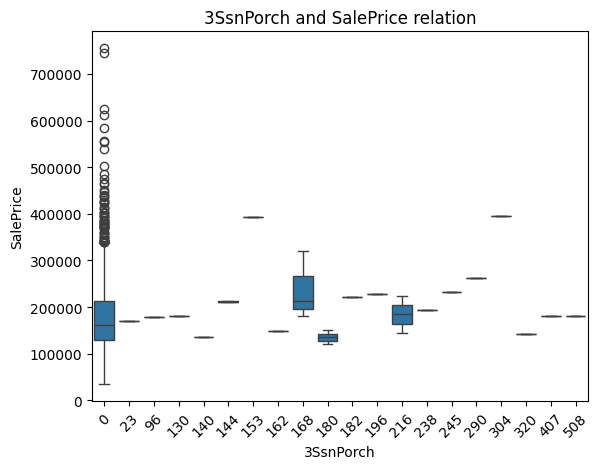

In [42]:
sns.boxplot(x = '3SsnPorch', y = 'SalePrice', data = data)

plt.xticks(rotation = 45)
plt.title('3SsnPorch and SalePrice relation')
plt.show()

In [43]:
#from the box plot we can see that '3SsnPorch' > 0 doesn't make much of a difference
#that means we should drop 3SsnPorch column
data.drop('3SsnPorch', axis=1, inplace=True)

In [44]:
#checking ScreenPorch column
data['ScreenPorch'].value_counts()

ScreenPorch
0      1344
192       6
120       5
224       5
189       4
       ... 
155       1
220       1
119       1
165       1
40        1
Name: count, Length: 76, dtype: int64

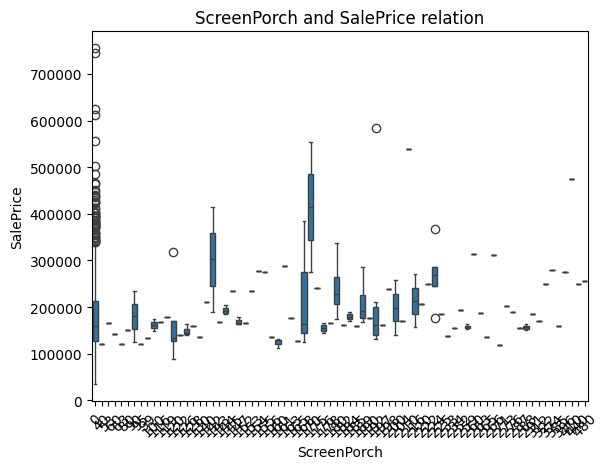

In [45]:
sns.boxplot(x='ScreenPorch', y='SalePrice', data=data)
plt.xticks(rotation=45)
plt.title('ScreenPorch and SalePrice relation')
plt.show()

In [46]:
#the saleprice for 0 ScreenPorch houses is around 100k to 200k, with some noises
#it's seen that the saleprice for other houses is also around that range, of course, with some noises
#this ScreenPorch will not be much useful, so I think I better drop it
data.drop('ScreenPorch', axis=1, inplace=True)

In [47]:
data['PoolArea'].value_counts()

PoolArea
0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64

In [48]:
#easy drop
data.drop('PoolArea', axis=1, inplace=True)

In [49]:
data['PoolQC'].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

In [50]:
#easy drop
data.drop('PoolQC', axis=1, inplace=True)

In [55]:
#checking Fence column
print(data['Fence'].value_counts(dropna=False))
#much info, better to keep it, and assign special value to Nan
data.loc[data['Fence'].isna(), 'Fence'] = 'None'

Fence
None     1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64


In [57]:
data['MiscFeature'].value_counts(dropna=False)


MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

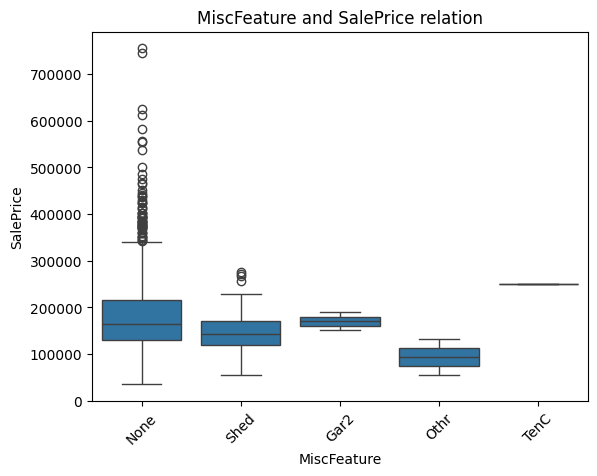

In [59]:
data['MiscFeature'].fillna('None', inplace=True)
sns.boxplot(x='MiscFeature', y='SalePrice', data=data)
plt.xticks(rotation=45)
plt.title('MiscFeature and SalePrice relation')
plt.show()

In [60]:
#houses with non 'None' MiscFeature doesn't have that much of a difference in price, better drop this column
data.drop('MiscFeature', axis=1, inplace=True)

In [61]:
#which means we should drop MiscVal too
data.drop('MiscVal', axis=1, inplace=True)

In [62]:
#checking SaleType column
data['SaleType'].value_counts()

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

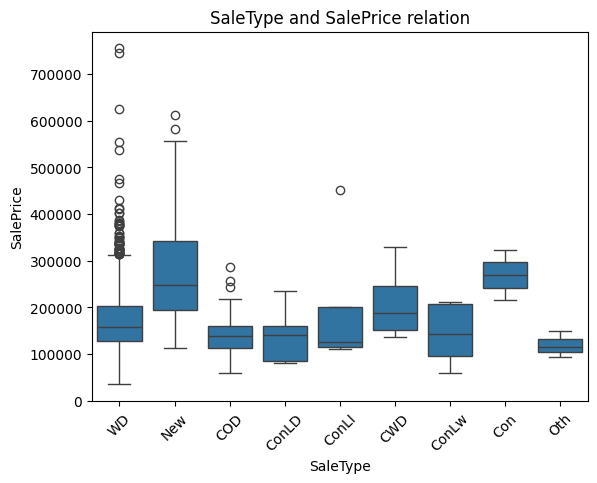

In [64]:
sns.boxplot(x='SaleType', y='SalePrice', data=data)
plt.xticks(rotation=45)
plt.title('SaleType and SalePrice relation')
plt.show()

In [67]:
#not many stuff other than 'WD', 'New' and 'COD', and their values are scattered
#better group them into 'Other'
data.loc[~data['SaleType'].isin(['WD', 'New', 'COD']), 'SaleType'] = 'Other'

In [68]:
data['SaleType'].value_counts()

SaleType
WD       1267
New       122
COD        43
Other      28
Name: count, dtype: int64

In [69]:
#checking SaleCondition column
data['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

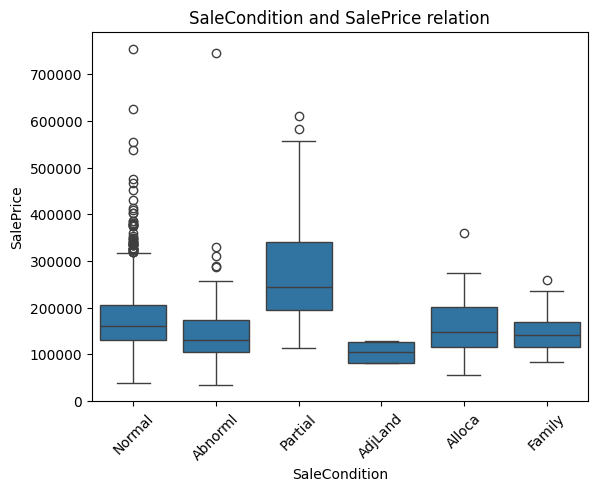

In [70]:
sns.boxplot(x='SaleCondition', y='SalePrice', data=data)
plt.xticks(rotation=45)
plt.title('SaleCondition and SalePrice relation')
plt.show()

In [71]:
data.loc[~data['SaleCondition'].isin(['Normal', 'Partial']), 'SaleCondition'] = 'Other'
data['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Other       137
Partial     125
Name: count, dtype: int64

In [ ]:
#cleaning is done, now I'll put the cleaned data in a csv file
data.to_csv('Cleaned_Data.csv', index=False)

In [8]:
def clean_house_data(df):
    #All the changes I made myself
    
    # Make a copy to avoid modifying original
    data = df.copy()
    
    # Drop unnecessary columns (based on EDA: redundant, low variance, or weak correlation)
    columns_to_drop = [
        'Utilities', 'Street', 'Condition2', 'RoofMatl', 
        'BsmtFinSF1', 'BsmtFinSF2', 'Heating', 'LowQualFinSF', 
        '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 
        'MiscFeature', 'MiscVal'
    ]
    data.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')
    
    # Transform BsmtHalfBath: group >0 into 1 (has half bath vs not)
    data.loc[data['BsmtHalfBath'] > 0, 'BsmtHalfBath'] = 1
    
    # Transform KitchenAbvGr: group !=1 into 0 (1 kitchen vs multiple/none)
    data.loc[data['KitchenAbvGr'] != 1, 'KitchenAbvGr'] = 0
    
    # Transform GarageQual: group != 'TA' into 'Other'
    data.loc[data['GarageQual'] != 'TA', 'GarageQual'] = 'Other'
    
    # Transform GarageCond: group != 'TA' into 'Other'
    data.loc[data['GarageCond'] != 'TA', 'GarageCond'] = 'Other'
    
    # Transform EnclosedPorch: group >0 into 1 (has porch vs not)
    data.loc[data['EnclosedPorch'] > 0, 'EnclosedPorch'] = 1
    
    # Fill Fence NaNs with 'None'
    data['Fence'].fillna('None', inplace=True)
    
    # Transform SaleType: group rare types into 'Other'
    data.loc[~data['SaleType'].isin(['WD', 'New', 'COD']), 'SaleType'] = 'Other'
    
    # Transform SaleCondition: group rare conditions into 'Other'
    data.loc[~data['SaleCondition'].isin(['Normal', 'Partial']), 'SaleCondition'] = 'Other'
    
    return data


In [9]:
data = clean_house_data(data)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31916\2213832374.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Fence'].fillna('None', inplace=True)


In [10]:
#cleaning is done, now I'll put the cleaned data in a csv file
data.to_csv('Cleaned_Data.csv', index=False)